# 02 · Cleaning Pipeline — from 590 raw sensors to a model-ready dataset

The pipeline lives in [`src/preprocessing.py`](../src/preprocessing.py) and is covered by unit tests in
[`tests/test_preprocessing.py`](../tests/test_preprocessing.py).

```
raw sensors ─► DropHighMissing(>50%) ─► DropConstant ─► Median impute ─► DropCorrelated(|r|>0.95) ─► StandardScaler
```

**Leakage control.** Notebook 01 showed the fail rate drifting from ~22% (July) to ~3% (September),
so the data is split **chronologically** (first 75% of units = train, last 25% = test) and *every*
pipeline decision — which sensors to drop, median values, scaling — is learned on the train period only.

In [1]:
import sys, json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.preprocessing import main as run_pipeline

FIG_DIR = ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid", context="notebook")
PASS_C, FAIL_C = "#2a9d8f", "#e76f51"

report = run_pipeline()

Sensors: 590 raw -> -24 high-missing -> -122 constant -> -172 correlated = 272 final
train: 1175 units, 80 fails (6.8%), 2008-07-19 -> 2008-09-29
test : 392 units, 24 fails (6.1%), 2008-09-29 -> 2008-10-17


## 1. Sensor reduction funnel

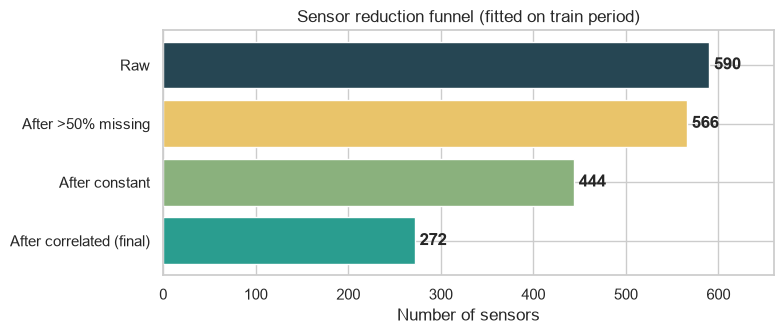

In [2]:
stages = ["Raw", "After >50% missing", "After constant", "After correlated (final)"]
values = [report["raw_sensors"]]
for k in ["dropped_high_missing", "dropped_constant", "dropped_correlated"]:
    values.append(values[-1] - report[k])

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(stages[::-1], values[::-1], color=["#2a9d8f", "#8ab17d", "#e9c46a", "#264653"])
for b, v in zip(bars, values[::-1]):
    ax.text(v + 5, b.get_y() + b.get_height() / 2, str(v), va="center", fontweight="bold")
ax.set_xlabel("Number of sensors")
ax.set_title("Sensor reduction funnel (fitted on train period)")
ax.set_xlim(0, 660)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_sensor_funnel.png", dpi=150)
plt.show()

**Result:** 590 → **272 sensors** (−54%). Counts differ slightly from notebook 01
(24 vs 28 high-missing, 122 vs 116 constant) because here they are computed on the **train period only** —
exactly what a production system would see at training time.

## 2. Train / test split over time

,units,fails,fail_rate,from,to
train,1175,80,6.8%,2008-07-19,2008-09-29
test,392,24,6.1%,2008-09-29,2008-10-17


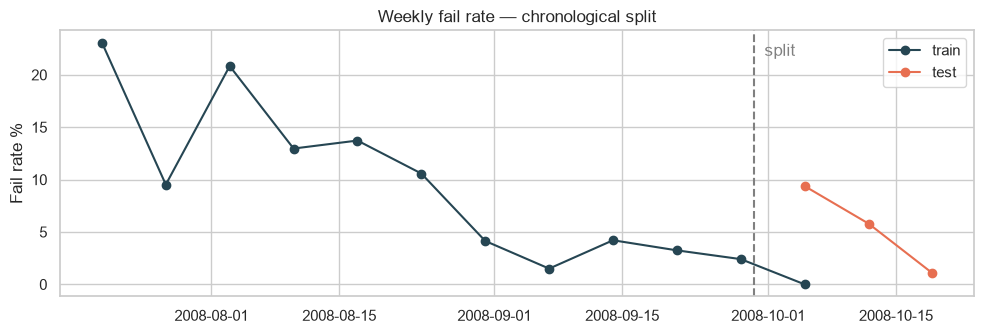

In [3]:
train = pd.read_csv(ROOT / "data/processed/train_clean.csv", parse_dates=["timestamp"])
test = pd.read_csv(ROOT / "data/processed/test_clean.csv", parse_dates=["timestamp"])

split = pd.DataFrame({
    "units": [len(train), len(test)],
    "fails": [train.fail.sum(), test.fail.sum()],
    "fail_rate": [train.fail.mean(), test.fail.mean()],
    "from": [train.timestamp.min().date(), test.timestamp.min().date()],
    "to": [train.timestamp.max().date(), test.timestamp.max().date()],
}, index=["train", "test"])
display(split.style.format({"fail_rate": "{:.1%}"}))

both = pd.concat([train.assign(set="train"), test.assign(set="test")])
weekly = both.set_index("timestamp").groupby("set")["fail"].resample("W").agg(["count", "mean"]).reset_index()
weekly = weekly[weekly["count"] > 0]

fig, ax = plt.subplots(figsize=(10, 3.5))
for name, c in [("train", "#264653"), ("test", FAIL_C)]:
    w = weekly[weekly.set == name]
    ax.plot(w.timestamp, w["mean"] * 100, marker="o", color=c, label=name)
ax.axvline(test.timestamp.min(), color="grey", ls="--")
ax.text(test.timestamp.min(), ax.get_ylim()[1] * 0.9, "  split", color="grey")
ax.set(title="Weekly fail rate — chronological split", ylabel="Fail rate %")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "02_time_split.png", dpi=150)
plt.show()

Only **24 failures** in the test period — small, so later metrics must be read with confidence
intervals in mind. The train period contains the high-failure excursion (July–August), the test period
is the recovered process plus the early-October spike.

## 3. Drift check — does the test period look like the train period?

After scaling, train sensors have mean 0 and std 1. A test-period mean far from 0 means that sensor drifted.

In [4]:
sensors = [c for c in test.columns if c.startswith("sensor_")]
shift = test[sensors].mean().abs().sort_values(ascending=False)
print(f"Median |shift| across sensors: {shift.median():.2f} σ")
print(f"Sensors shifted > 1 σ: {(shift > 1).sum()}  |  > 3 σ: {(shift > 3).sum()}")
shift.head(8).round(1).to_frame("|test mean| in train σ")

Median |shift| across sensors: 0.15 σ
Sensors shifted > 1 σ: 6  |  > 3 σ: 3


,|test mean| in train σ
sensor_140,321.2
sensor_004,30.5
sensor_252,4.6
sensor_132,1.1
sensor_007,1.1
sensor_056,1.0
sensor_571,0.9
sensor_316,0.9


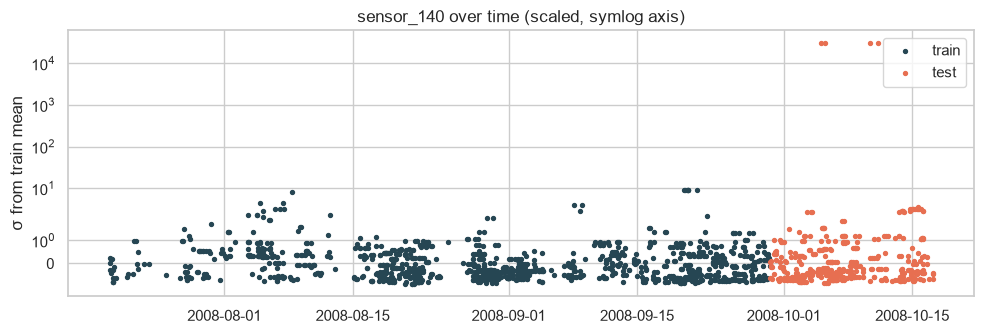

In [5]:
s = shift.index[0]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.scatter(train.timestamp, train[s], s=8, color="#264653", label="train")
ax.scatter(test.timestamp, test[s], s=8, color=FAIL_C, label="test")
ax.set_yscale("symlog")
ax.set(title=f"{s} over time (scaled, symlog axis)", ylabel="σ from train mean")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "02_drift_top_sensor.png", dpi=150)
plt.show()

**Observation:** the process is broadly stable between periods (median shift ≈ 0.15σ), but a
handful of sensors — especially **`sensor_140`** — jump to extreme values in the test period.
This is exactly the kind of event SPC monitoring (Step 3) and anomaly detection (Step 6) should flag.

## 4. Outputs of this step

| File | Content |
|---|---|
| `data/processed/train_clean.csv` | 1175 units × 272 scaled sensors + unit_id, timestamp, fail |
| `data/processed/test_clean.csv` | 392 units, same columns, transformed with the train-fitted pipeline |
| `data/processed/cleaning_report.json` | Counts + exact list of every dropped sensor and why |
| `models/preprocessor.joblib` | Fitted pipeline — reused by the model and the Streamlit app for new units |